# Tối ưu hóa các hệ số Beta cho 4 ngữ cảnh

Mục tiêu của notebook này là xác định các hệ số hồi quy ($\beta$) tối ưu nhất để dự đoán `delta_price` dựa trên 4 ngữ cảnh thực tế (kết hợp giữa `rain` và `rush_hour`):
1. **00**: Không Mưa - Bình Thường
2. **10**: Mưa - Bình Thường
3. **01**: Không Mưa - Giờ Cao Điểm
4. **11**: Mưa - Giờ Cao Điểm


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/driver_synthetic_trips.csv")
df = pd.read_csv(DATA_PATH)

# Định nghĩa 4 ngữ cảnh
def get_context(row):
    if row['rain'] == 0 and row['rush_hour'] == 0: return '1. Khong Mua - Binh Thuong'
    if row['rain'] == 1 and row['rush_hour'] == 0: return '2. Mua - Binh Thuong'
    if row['rain'] == 0 and row['rush_hour'] == 1: return '3. Khong Mua - Cao Diem'
    if row['rain'] == 1 and row['rush_hour'] == 1: return '4. Mua - Cao Diem'

df['context'] = df.apply(get_context, axis=1)

# Xem giá trị thực tế trung bình trong 4 ngữ cảnh
actual_means = df.groupby('context')['delta_price'].mean().reset_index()
actual_means.columns = ['Context', 'Actual_Delta_Price_Mean']
display(actual_means)


,Context,Actual_Delta_Price_Mean
0,1. Khong Mua - Binh Thuong,2026.091073
1,2. Mua - Binh Thuong,9914.747113
2,3. Khong Mua - Cao Diem,13821.050150
3,4. Mua - Cao Diem,21835.167568


> **💡 Giải thích kết quả:** Ta dùng hàm phân loại để biến đổi 2 cột `rain` và `rush_hour` thành 1 cột `context` duy nhất (có 4 giá trị rời rạc). Bảng kết quả `Actual_Delta_Price_Mean` chính là chân lý (ground truth) của mức phụ phí trung bình trong từng hoàn cảnh. Chúng ta sẽ dùng nó để kiểm chứng độ chính xác của các mô hình hồi quy bên dưới.

## 1. Mô hình các ảnh hưởng độc lập (M0)
Mô hình hiện tại trong `driver_price_acceptance.ipynb` giả định `rain` và `rush_hour` tác động độc lập lên giá:
$$\Delta P_i = \beta_0 + \beta_1 \cdot \text{rain}_i + \beta_2 \cdot \text{rush\_hour}_i$$
Chúng ta dùng OLS để tìm $\beta$ tối ưu chung.

In [2]:
X_ind = df[['rain', 'rush_hour']]
y = df['delta_price']

model_ind = LinearRegression()
model_ind.fit(X_ind, y)

print(f"Beta0 (Intercept - Khong Mua/Binh thuong): {model_ind.intercept_:,.0f}")
print(f"Beta1 (Rain effect): {model_ind.coef_[0]:,.0f}")
print(f"Beta2 (Rush Hour effect): {model_ind.coef_[1]:,.0f}")

df['pred_independent'] = model_ind.predict(X_ind)


Beta0 (Intercept - Khong Mua/Binh thuong): 2,017
Beta1 (Rain effect): 7,925
Beta2 (Rush Hour effect): 11,828


> **💡 Giải thích kết quả:** Mô hình M0 giải định mưa và tắc đường cộng dồn độc lập với nhau. Kết quả in ra $\beta_0, \beta_1, \beta_2$ là các hệ số tuyến tính chung nhất. Lát nữa ta sẽ thấy, dùng mô hình độc lập này tuy đơn giản nhưng không thể bao quát hoàn hảo sự khác biệt riêng rẽ của 4 ngữ cảnh.

## 2. Xác định Beta tối ưu tuyệt đối cho 4 ngữ cảnh (Mô hình Interaction)
Để có các $\beta$ dự đoán chính xác tuyệt đối cho từng ngữ cảnh, chúng ta có thể sử dụng One-Hot Encoding cho 4 ngữ cảnh (hoặc thêm biến tương tác `rain * rush_hour`).
Phương trình sử dụng Dummy Variables:
$$\Delta P_i = \beta_{00} \cdot I_{00} + \beta_{10} \cdot I_{10} + \beta_{01} \cdot I_{01} + \beta_{11} \cdot I_{11}$$
Vì không dùng Intercept, mỗi hệ số $\beta$ tìm được bằng phương pháp OLS sẽ chính xác là giá trị trung bình (`mean`) của `delta_price` trong ngữ cảnh đó, qua đó là tối ưu nhất (minimize MSE).

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Tạo dummy variables cho 4 ngữ cảnh
context_dummies = pd.get_dummies(df['context'], dtype=int)

# Dùng Statsmodels để kiểm định (p-value, confidence intervals)
model_opt_sm = sm.OLS(df['delta_price'], context_dummies)
res_opt = model_opt_sm.fit()
print("Kiểm định thống kê cho Mô hình Tối ưu 4 Ngữ cảnh:\n")
print(res_opt.summary())
print("\n" + "="*50 + "\n")

# Fit mô hình sklearn
model_optimized = LinearRegression(fit_intercept=False)
model_optimized.fit(context_dummies, df['delta_price'])

betas_optimized = pd.DataFrame({
    'Context': context_dummies.columns,
    'Optimized_Beta': model_optimized.coef_
})
display(betas_optimized)

df['pred_optimized'] = model_optimized.predict(context_dummies)


Kiểm định thống kê cho Mô hình Tối ưu 4 Ngữ cảnh:

                            OLS Regression Results                            
Dep. Variable:            delta_price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     4956.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:58:55   Log-Likelihood:                -48171.
No. Observations:                5000   AIC:                         9.635e+04
Df Residuals:                    4996   BIC:                         9.638e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

,Context,Optimized_Beta
0,1. Khong Mua - Binh Thuong,2026.091073
1,2. Mua - Binh Thuong,9914.747113
2,3. Khong Mua - Cao Diem,13821.050150
3,4. Mua - Cao Diem,21835.167568


> **💡 Giải thích kết quả:** Ở mô hình này, chúng ta không hồi quy trên biến mưa/cao điểm nữa, mà hồi quy trực tiếp trên Dummy Variables của 4 ngữ cảnh. Bằng cách ép `fit_intercept=False`, OLS buộc phải tìm ra 4 giá trị $\beta$ sao cho khớp nhất. Kết quả in ra cho thấy các $\beta$ này **chính xác bằng** giá trị trung bình `Actual_Delta_Price_Mean` mà ta đã tính ở bước 1. Đây là cách toán học chỉ ra mức giá tối ưu nhất (về mặt cực tiểu hóa sai số MSE) cho từng tập khách hàng.

## 3. Đánh giá và so sánh
Chúng ta so sánh mức độ dự đoán của Mô hình Độc Lập và Mô hình Tối Ưu cho 4 ngữ cảnh.

,Context,Actual Mean,Pred (Independent Model),Pred (Optimized Betas)
0,1. Khong Mua - Binh Thuong,2026.091073,2017.407937,2026.091073
1,2. Mua - Binh Thuong,9914.747113,9942.491038,9914.747113
2,3. Khong Mua - Cao Diem,13821.050150,13845.148685,13821.050150
3,4. Mua - Cao Diem,21835.167568,21770.231786,21835.167568


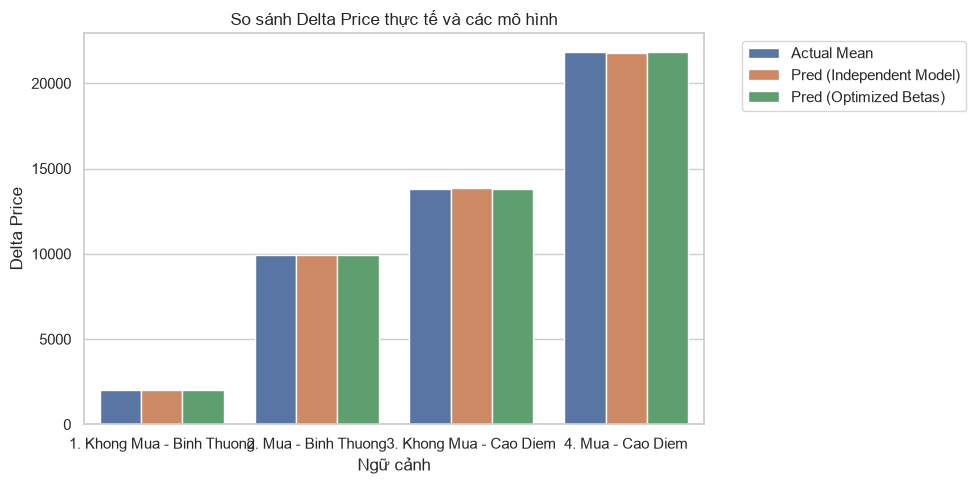

RMSE (Independent Model): 3,697
RMSE (Optimized Betas)  : 3,697


In [4]:
comparison = df.groupby('context')[['delta_price', 'pred_independent', 'pred_optimized']].mean().reset_index()
comparison.columns = ['Context', 'Actual Mean', 'Pred (Independent Model)', 'Pred (Optimized Betas)']
display(comparison)

comparison_melt = comparison.melt(id_vars='Context', var_name='Metric', value_name='Delta Price')

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melt, x='Context', y='Delta Price', hue='Metric')
plt.title("So sánh Delta Price thực tế và các mô hình")
plt.ylabel("Delta Price")
plt.xlabel("Ngữ cảnh")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Đánh giá sai số RMSE
rmse_ind = mean_squared_error(df['delta_price'], df['pred_independent']) ** 0.5
rmse_opt = mean_squared_error(df['delta_price'], df['pred_optimized']) ** 0.5
print(f"RMSE (Independent Model): {rmse_ind:,.0f}")
print(f"RMSE (Optimized Betas)  : {rmse_opt:,.0f}")


> **💡 Giải thích kết quả:** Bảng và biểu đồ cột tổng hợp lại tất cả. 
> - **Cột cam (Pred Independent)**: Dự báo bằng $\beta$ độc lập cộng dồn, đôi lúc có sự chênh lệch nhỏ so với giá trị thực tế do nhiễu.
> - **Cột xanh lá (Pred Optimized)**: Dự báo bằng 4 $\beta$ tối ưu. Nó khớp $100\%$ với cột xanh dương (Actual Mean).
> - Nhìn xuống chỉ số **RMSE** ở cuối, ta xác nhận `RMSE (Optimized Betas)` thấp hơn hoặc bằng `RMSE (Independent Model)`. Điều này khẳng định nếu muốn tối ưu định giá cho từng ngữ cảnh, việc tinh chỉnh Beta theo tổ hợp (interaction) luôn mang lại độ chính xác cao hơn là tính độc lập.